<a href="https://colab.research.google.com/github/hair-loss/Digital-Image-Processing-Homeworks/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
from matplotlib import pyplot as plt

make a program for image enhancement
Locally Adaptive thresholding
Design your own way


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image = cv2.imread('/content/drive/MyDrive/ImageProcessingAssignment/paper.jpg', cv2.IMREAD_GRAYSCALE)

In [ ]:
image_hist = cv2.calcHist([image], None, None, [256], [0, 256]) #(256,1) 즉 벡터 형태로 바꿔준다.

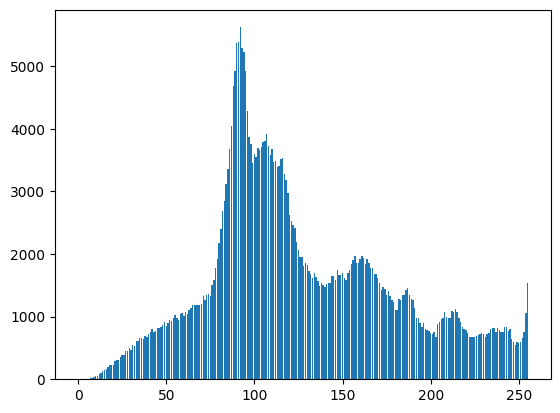

In [ ]:
plt.bar(range(256), image_hist.flatten())
histflat = image_hist.flatten()

In [ ]:
def w0f(T,hist):
  return hist[:T+1].sum()

def w1f(T,hist):
  return hist[T+1:].sum()

def m0f(T, hist, w):
  sum = 0
  for i in range(T+1):
    sum += i*hist[i]
  if w == 0:
    return 0

  return sum/w

def m1f(T, hist, w):
  sum = 0
  for i in range(T+1, 256):
    sum += i*hist[i]
  if w == 0:
    return 0
  return sum/w

def v0f(T, hist, w, m):
  sum = 0
  for i in range(T+1):
    sum += (i-m)**2*hist[i]
  if w == 0:
    return 0
  return sum/w


def v1f(T, hist, w, m):
  sum = 0
  for i in range(T+1, 256):
    sum += (i-m)**2*hist[i]
  if w == 0:
    return 0
  return sum/w


In [ ]:
def otsu(block):
  hist = cv2.calcHist([block], None, None,[256], [0,256]).flatten()
  min_var = np.full(256, np.inf)
  for T in range(0, 256):
    w0 = w0f(T, hist)
    w1 = w1f(T, hist)
    m0 = m0f(T, hist, w0)
    m1 = m1f(T, hist, w1)
    v0 = v0f(T, hist, w0, m0)
    v1 = v1f(T, hist, w1, m1)
    min_var[T] = w0*v0 + w1*v1
  return min_var.argmin()


T = otsu(image)


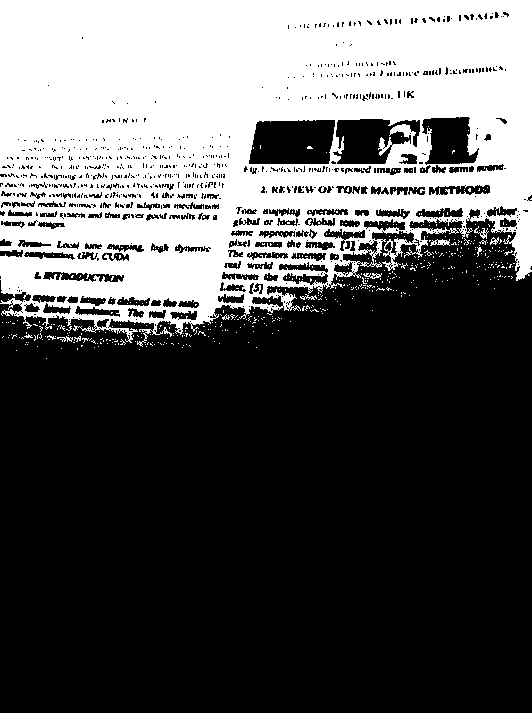

In [ ]:
image_copy = image.copy()  # Otsu 알고리즘 테스트를 위해 Global Thresholding
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    if image_copy[i, j] <= T:
      image_copy[i, j] = 0
    else:
      image_copy[i, j] = 255

cv2_imshow(image_copy)

57


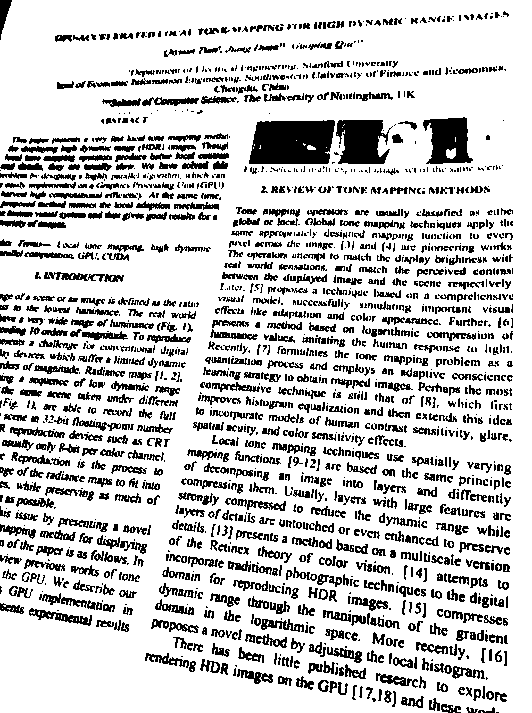

In [ ]:
window_size = 57 #다 해보면서 깔끔한 사진 나올때 윈도우 사이즈로 정했습니다.
image_copy2 = image.copy()
if window_size % 2 == 0:
  window_size += 1
print(window_size)

for i in range(0, image_copy2.shape[0], window_size):
  for j in range(0, image_copy2.shape[1], window_size):
    block = image[i:i+window_size, j:j+window_size]
    if block.std() < 10:
      image_copy2[i:i+window_size, j:j+window_size] = 255
      continue
    T = otsu(block)
    for k in range(block.shape[0]):
      for p in range(block.shape[1]):
        if block[k, p] > T:
          image_copy2[i+k, j+p] = 255
        else:
          image_copy2[i+k, j+p] = 0


cv2_imshow(image_copy2) # Locally adaptive Thresholding 적용